In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore")
from sklearn.decomposition import PCA


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv("global_ai_workforce_automation_2015_2025.csv")
df.head()

,Year,Country,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,2015,United States,52.46,10.75,65.50,38392.64,65.78,709.03,0.64,0.19,0.14,47.87
1,2016,United States,60.64,11.64,65.25,39371.74,67.02,815.38,0.75,0.16,0.85,43.85
2,2017,United States,66.11,12.46,64.93,40772.29,68.51,921.74,0.51,0.17,1.23,37.13
3,2018,United States,72.45,13.35,64.84,43974.92,71.09,1028.09,0.69,0.27,0.76,42.28
4,2019,United States,79.11,14.65,64.55,43745.39,69.89,1134.45,0.57,0.25,0.85,43.95


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              220 non-null    int64  
 1   Country                           220 non-null    object 
 2   AI_Investment_BillionUSD          220 non-null    float64
 3   Automation_Rate_Percent           220 non-null    float64
 4   Employment_Rate_Percent           220 non-null    float64
 5   Average_Salary_USD                220 non-null    float64
 6   Productivity_Index                220 non-null    float64
 7   Reskilling_Investment_MillionUSD  220 non-null    float64
 8   AI_Policy_Index                   220 non-null    float64
 9   Job_Displacement_Million          220 non-null    float64
 10  Job_Creation_Million              220 non-null    float64
 11  AI_Readiness_Score                220 non-null    float64
dtypes: float

In [4]:
# Pre-processing
df_country = df.groupby("Country").mean(numeric_only=True).reset_index()

In [5]:
# Feature Selection
# features = [
#     'AI_Investment_BillionUSD',
#     'Automation_Rate_Percent',
#     'Employment_Rate_Percent',
#     'Average_Salary_USD',
#     'Productivity_Index',
#     'Reskilling_Investment_MillionUSD',
#     'AI_Policy_Index',
#     'Job_Displacement_Million',
#     'Job_Creation_Million',
#     'AI_Readiness_Score'
# ]

# features = [
#     'AI_Investment_BillionUSD',
#     'Automation_Rate_Percent',
#     'Reskilling_Investment_MillionUSD',
#     'Productivity_Index',
#     'AI_Policy_Index',
#     'AI_Readiness_Score'
# ]

features = [
    'AI_Investment_BillionUSD',
    'Automation_Rate_Percent',
    'Employment_Rate_Percent',
    'Productivity_Index',
    'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index',
    'Job_Displacement_Million',
    'Job_Creation_Million',
    'AI_Readiness_Score'
]

In [19]:
# Feature Matrix
X = df_country[features]
X.head()

,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,85.682727,33.280000,62.110909,53.221818,772.642727,0.640909,0.388182,1.515455,46.173636
1,127.274545,34.072727,69.430000,77.448182,1397.200000,0.468182,0.470000,2.270909,47.099091
2,83.683636,25.737273,65.887273,56.115455,1650.230909,0.630000,0.271818,1.196364,43.651818
3,115.186364,17.590000,66.632727,54.383636,970.934545,0.627273,0.285455,1.830000,39.799091
4,107.251818,33.815455,75.582727,70.876364,247.172727,0.516364,0.373636,1.491818,45.388182


In [20]:
# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Task was destroyed but it is pending!
task: <Task pending name='Task-140' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\cdvincoy\AppData\Roaming\Python\Python313\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-141' coro=<Kernel.shell_main() running at C:\Users\cdvincoy\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\cdvincoy\AppData\Roaming\Python\Python313\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-141' coro=<Kernel.shell_main() running at C:\Users\cdvincoy\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


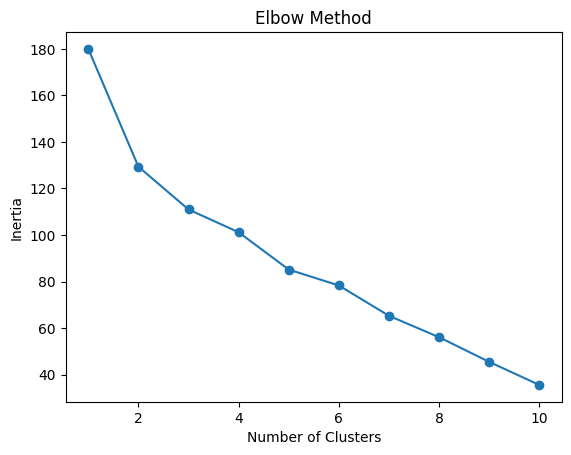

In [21]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_country['Cluster'] = kmeans.fit_predict(X_scaled)

In [28]:
df_country[['Country', 'Cluster']].head()

,Country,Cluster
0,Australia,0
1,Brazil,1
2,Canada,2
3,China,0
4,France,1


In [29]:
df_country.groupby('Cluster')[features].mean()

,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
Cluster,,,,,,,,,
0,79.551136,25.990455,69.575682,51.601705,746.427159,0.615341,0.370909,1.217727,41.520227
1,107.927013,34.071429,69.285195,70.746494,797.785325,0.573247,0.441558,1.622338,47.027792
2,51.078000,20.123818,66.955273,60.850182,1448.655818,0.630909,0.250909,0.771455,43.418000


In [30]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

df_country.groupby("Cluster")["Country"].apply(list)

Cluster
0    [Australia, China, Germany, Italy, Singapore, Spain, Turkey, United Kingdom]
1         [Brazil, France, Japan, Mexico, Netherlands, South Africa, South Korea]
2                                  [Canada, India, Russia, Sweden, United States]
Name: Country, dtype: object

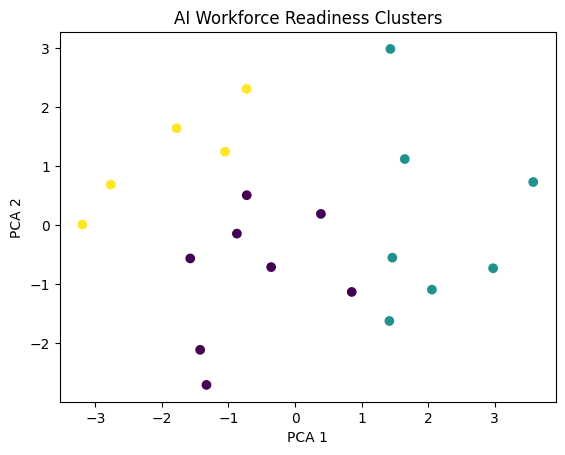

In [31]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.scatter(components[:,0], components[:,1], c=df_country['Cluster'])
plt.title("AI Workforce Readiness Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()